In [20]:
import os
import numpy as np
import torch

from printer import print_batch
from cosmos_predict2.data.action_conditioned.libero_dataset import LiberoReplayImageDataset

In [21]:
dataset = LiberoReplayImageDataset(
    shape_meta={
        "image_resolution": 128,
        "action": {
            "shape": [10]
        },
        "obs": {
            "agentview_rgb": {
                "shape": [3, 128, 128],
                "type": "rgb"
            },
            "language": {
                "shape": [15],
            }
        }
    },
    dataset_path="/home/geyuan/datasets/LIBERO_uva25rss/libero_10",
    horizon=33,  # max length of each clip
    pad_before=4 * 2,  # m_obs-1
    pad_after=1,
    n_obs_steps=4 * 2 + 1,  # not used
    abs_action=True,
    rotation_rep="rotation_6d",
    use_cache=True,
    seed=42,
    val_ratio=0.01,  # ori: 0.02
    language_emb_model="t5xxl",  # ori: "clip"
    data_aug=True,
    normalizer_type="all",  # not used
    # extra args for cache building,
    cache_zarr_path="/home/geyuan/datasets/LIBERO_uva25rss/"
                    "libero_10_full_clip_t5xxl.zarr.zip",
)
print(len(dataset))

Acquiring lock on cache.
Cache path: /home/geyuan/datasets/LIBERO_uva25rss/libero_10_full_clip_t5xxl.zarr.zip
Loading cached ReplayBuffer from Disk.
Loaded!
---------------------------------------------------------
Validation episodes: [384 219 325  44 216]
---------------------------------------------------------
[LiberoDataset] action: 
mean: -0.0410,	0.0349,	0.8389,	0.3086,	0.6320,	-0.0298,	0.6294,	-0.2721,	0.1521,	-0.1065 
std: 0.1048,	0.1465,	0.2572,	0.5414,	0.4351,	0.1485,	0.4493,	0.4955,	0.2436,	0.9941 
min: -0.5226,	-0.3341,	0.4075,	-1.0000,	-0.7127,	-0.6373,	-0.8550,	-1.0000,	-0.6161,	-1.0000 
max: 0.2064,	0.3886,	1.3320,	1.0000,	1.0000,	0.6735,	1.0000,	0.9999,	0.9838,	1.0000
[LiberoDataset] using t5xxl model for language embedding. found 10 unique texts
125301


In [ ]:
normalizer = dataset.get_normalizer()
print(type(normalizer))
print(normalizer['action'].params_dict.keys())
print('mean', normalizer['action'].params_dict['input_stats'].mean)
print('std',normalizer['action'].params_dict['input_stats'].std)
print('min',normalizer['action'].params_dict['input_stats'].min)
print('max',normalizer['action'].params_dict['input_stats'].max)
print(normalizer['action'].params_dict['offset'])
print(normalizer['action'].params_dict['scale'])

# in_action = dataset[1]['action']
# print("in_action:", in_action.shape, in_action.min(), in_action.max(), in_action.mean(), in_action.std())
# norm_action = normalizer['action'].unnormalize(in_action)
# print("norm_action:", norm_action.shape, norm_action.min(), norm_action.max(), norm_action.mean(), norm_action.std())
#
# print(normalizer['action'].params_dict['scale'])

In [ ]:
from cosmos_predict2.utils.vis_helpers import save_action_as_image
from imaginaire.utils.io import save_image_or_video
import torch

max_vis_len = 50
# in_sample = {
#     'action':dataset.replay_buffer['action'].astype(np.float32),
#     'video': torch.from_numpy(np.array(dataset.replay_buffer['agentview_rgb'][:max_vis_len])).to(torch.uint8).permute(3, 0, 1, 2),
# }
in_sample = dataset[0]
print(in_sample['action'].shape)
print(in_sample['video'].shape)

in_action = in_sample['action']
# print("in_action:",
#       "\ndim0:", in_action[:, 0].min(), in_action[:, 0].max(),
#       "\ndim1:", in_action[:, 1].min(), in_action[:, 1].max(),
#       "\ndim2:", in_action[:, 2].min(), in_action[:, 2].max(),
#       "\ndim3:", in_action[:, 3].min(), in_action[:, 3].max(),
#       "\ndim4:", in_action[:, 4].min(), in_action[:, 4].max(),
#       "\ndim5:", in_action[:, 5].min(), in_action[:, 5].max(),
#       "\ndim6:", in_action[:, 6].min(), in_action[:, 6].max(),
#       "\ndim7:", in_action[:, 7].min(), in_action[:, 7].max(),
#       "\ndim8:", in_action[:, 8].min(), in_action[:, 8].max(),
#       "\ndim9:", in_action[:, 9].min(), in_action[:, 9].max(),
#       )
save_action_as_image(
    in_action[:max_vis_len, :3],
    "/home/geyuan/code/cospred2nvidia/output/de_libero10_in_action.png",
)

unnormed_action = dataset.denorm_action(
    in_action
)
save_action_as_image(
    unnormed_action[:max_vis_len, :3],
    "/home/geyuan/code/cospred2nvidia/output/de_libero10_in_unnormed_action.png",
)

in_video = in_sample['video']
save_image_or_video(
    in_video[:, :max_vis_len].to(torch.float32) / 255.,  # (c,t,h,w)
    "/home/geyuan/code/cospred2nvidia/output/de_libero10_in_video.mp4",
    fps=10
)

In [ ]:
sample = dataset[1]
# print_batch('sampled', dataset.sampler.sample_sequence(-1))
print_batch("sample", sample)
# print(len(dataset))
# print("['action']:", sample['action'][0])
# print("['obs']['language']:", sample['obs']['language'][0])

# from cosmos_predict2.data.action_conditioned.libero_dataset import array_to_stats
# print(dataset.replay_buffer['action'])
# print(array_to_stats(dataset.replay_buffer['action']))
# normalizer = dataset.get_normalizer()
# print(normalizer['action'].params_dict.keys())
# print(normalizer['action'].params_dict['input_stats'])
# print(normalizer['action'].params_dict['offset'])
# print(normalizer['action'].params_dict['scale'])

# from cosmos_predict2.data.action_conditioned.libero_dataset import AutoTokenizer
# tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-base-patch32")
# lang_token = sample['obs']['language']  # (horizon,2,30)
# text_tokens = {
#     "input_ids": lang_token[:, 0].long()[:, 0],
#     "attention_mask": lang_token[:, 0].long()[:, 1],
# }
# print("lang_token:", lang_token[0, 0])
# print(tokenizer.decode(lang_token[0, 0].long()))
# print(tokenizer.decode(lang_token[1, 0].long()))
# print(tokenizer.decode(lang_token[-1, 0].long()))
# print(language_emb_model.)

In [22]:
from cosmos_predict2.data.action_conditioned.libero_dataset import array_to_stats
print(dataset.replay_buffer.keys)
# print(dataset.replay_buffer['action'])
# print(dataset.replay_buffer['agentview_rgb'])
# print(dataset.replay_buffer['language'])
# print(dataset.replay_buffer['t5_text_indices'])
# print(array_to_stats(dataset.replay_buffer['action']))
# normalizer = dataset.get_normalizer()
# print(normalizer['action'].params_dict.keys())s
# print(normalizer['action'].params_dict['input_stats'])
# print(normalizer['action'].params_dict['offset'])
# print(normalizer['action'].params_dict['scale'])
data_t5_text_indices = dataset.replay_buffer['t5_text_indices']

''' DEBUG: t5 tokenizer '''
print("***" * 5, "DEBUG: t5 tokenizer", "***" * 5)
from transformers.models.t5 import T5EncoderModel, T5TokenizerFast
from cosmos_predict2.data.action_conditioned.libero_dataset import LiberoReplayImageDataset
t5_tokenizer = T5TokenizerFast.from_pretrained(
    pretrained_model_name_or_path="../checkpoints/google-t5/t5-11b",
    cache_dir="../checkpoints/google-t5/t5-11b",
    local_files_only=True,
)
meta_eps = dataset.replay_buffer.meta["episode_ends"]
meta_embeddings = dataset.replay_buffer.meta["t5_unique_embeddings"]
meta_texts = dataset.replay_buffer.meta["t5_unique_texts"]
meta_valid_lengths = dataset.replay_buffer.meta["t5_valid_lengths"]

print(meta_eps[0], meta_eps[-1])
print(np.array(meta_texts))
print(np.array(meta_valid_lengths))
print(np.array(meta_embeddings)[0].min(), np.array(meta_embeddings)[0].max())
print(len("living room scene 2 put both the cream cheese box and the butter in the basket"))

<bound method ReplayBuffer.keys of /
 ├── data
 │   ├── action (138090, 10) float32
 │   ├── agentview_rgb (138090, 128, 128, 3) uint8
 │   ├── ee_states (138090, 6) float32
 │   ├── eye_in_hand_rgb (138090, 128, 128, 3) uint8
 │   ├── gripper_states (138090, 2) float32
 │   ├── language (138090, 2, 30) int64
 │   └── t5_text_indices (138090,) int32
 └── meta
     ├── episode_ends (500,) int64
     ├── t5_unique_embeddings (10, 512, 1024) float16
     ├── t5_unique_texts (10,) <U512
     └── t5_valid_lengths (10,) int32>
*************** DEBUG: t5 tokenizer ***************
388 138090
['living room scene 2 put both the alphabet soup and the tomato sauce in the basket'
 'living room scene 6 put the white mug on the plate and put the chocolate pudding to the right of the plate'
 'kitchen scene 8 put both moka pots on the stove'
 'kitchen scene 3 turn on the stove and put the moka pot on it'
 'kitchen scene 6 put the yellow and white mug in the microwave and close it'
 'living room scene 1 

(128, 128, 3)


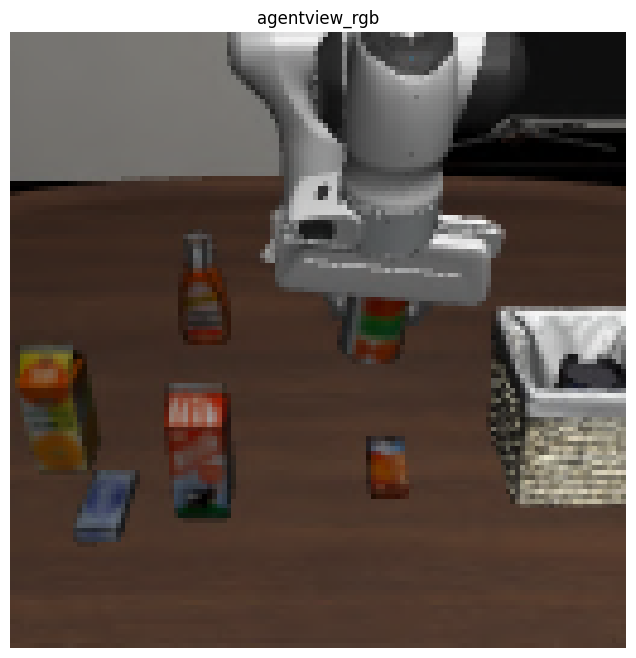

(128, 128, 3)


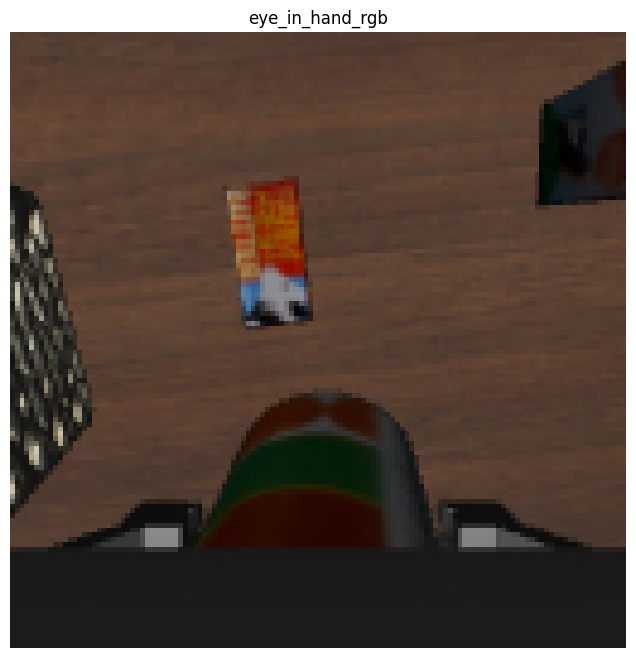

(100, 10)
[DEBUG] save_3d_action_as_image: (100, 3) float32 -0.16347937 0.6920136
[09-25 12:21:45|INFO|../../../../../../../home/geyuan/code/cospred2nvidia/cosmos_predict2/utils/vis_helpers.py:126:save_3d_action_as_image] Saved 3D action trajectory visualization to /home/geyuan/code/cospred2nvidia/output/de_libero10_action.png


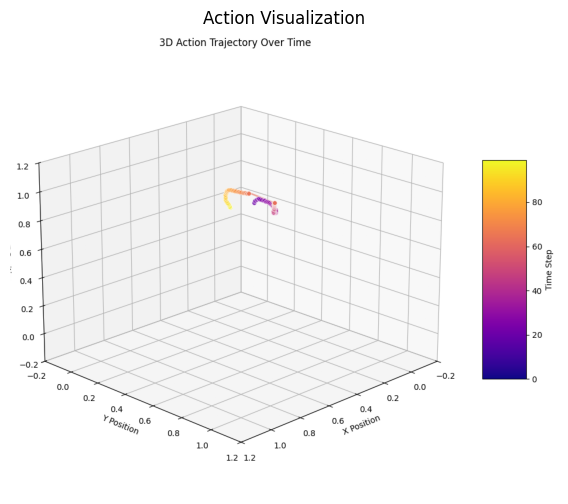

In [42]:
import matplotlib.pyplot as plt
from imaginaire.utils.io import save_image_or_video
from cosmos_predict2.utils.vis_helpers import save_action_as_image

# save_image_or_video(
#     dataset[1000]['obs']['agentview_rgb'].permute(1, 0, 2, 3),
#     "/home/geyuan/code/cospred2nvidia/output/de_libero10_sample.mp4",
#     fps=2
# )
cmp_index = 10000 + 100

# print("Ends compare:",
#       "\n", dataset.replay_buffer.meta['episode_ends'][0:cmp_index],
#       "\n", dataset_for_convert.replay_buffer.meta['episode_ends'][0:cmp_index])
#
# print("Shape compare:",
#       "\n", dataset.replay_buffer['agentview_rgb'],
#       "\n", dataset_for_convert.replay_buffer['agentview_rgb'])
#
# print("Value compare:",
#       "\n", dataset.replay_buffer['agentview_rgb'][cmp_index].min(), dataset.replay_buffer['agentview_rgb'][cmp_index].max(),
#       "\n", dataset_for_convert.replay_buffer['agentview_rgb'][cmp_index].min(), dataset_for_convert.replay_buffer['agentview_rgb'][cmp_index].max(),
#       )

def img_flip(img_hwc):
    ''' 上下颠倒 '''
    # return img_hwc
    # 旋转180度 (对H和W维度进行旋转)
    img = np.rot90(img_hwc, k=2, axes=(0, 1))
    # 水平翻转 (沿W维度翻转)
    img = np.flip(img, axis=1)
    return img

sample = dataset.replay_buffer['agentview_rgb'][cmp_index]
print(sample.shape)

vis_img = img_flip(sample)

plt.figure(figsize=(10, 8))
plt.imshow(vis_img)
plt.axis('off')  # 隐藏坐标轴
plt.title('agentview_rgb')
plt.show()

sample = dataset.replay_buffer['eye_in_hand_rgb'][cmp_index]
print(sample.shape)

vis_img = img_flip(sample)

plt.figure(figsize=(10, 8))
plt.imshow(vis_img)
plt.axis('off')  # 隐藏坐标轴
plt.title('eye_in_hand_rgb')
plt.show()

action = dataset.replay_buffer['action'][cmp_index: cmp_index + 100]
print(action.shape)
save_action_as_image(
    action[:, :3],
    "/home/geyuan/code/cospred2nvidia/output/de_libero10_action.png",
)
img_path = "/home/geyuan/code/cospred2nvidia/output/de_libero10_action.png"
img = plt.imread(img_path)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')  # 隐藏坐标轴
plt.title('Action Visualization')
plt.show()

# sample = dataset_for_convert.replay_buffer['agentview_rgb'][cmp_index]
# print(sample.shape)
#
# vis_img = sample
#
# plt.figure(figsize=(10, 8))
# plt.imshow(vis_img)
# plt.axis('off')  # 隐藏坐标轴
# plt.title('My Image')
# plt.show()

In [7]:
""" Check HDF5 file """
import os
import h5py
import numpy as np

# 检查数据结构
file_path = "/home/geyuan/datasets/LIBERO_uva25rss/libero_10/KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it_demo.hdf5"
with h5py.File(file_path, 'r') as f:
    demo = f['data']['demo_0']
    print("Available obs keys:", list(demo['obs'].keys()))

    # 检查是否有机械臂位置相关的 key
    for key in demo['obs'].keys():
        print(f"{key}: shape={demo['obs'][key].shape}")

    print("joint_states:", demo['obs']['joint_states'][0])
    print("ee_pos:", demo['obs']['ee_pos'][0])
    print("ee_ori:", demo['obs']['ee_ori'][0])
    print("ee_states:", demo['obs']['ee_states'][0])
    print("gripper_states:", demo['obs']['gripper_states'][0])

    print("action:", np.array(demo['actions'][:, 0]).min(), np.array(demo['actions'][:, 0]).max(), demo['actions'].shape)


# import robomimic.utils.file_utils as FileUtils
# env_meta = FileUtils.get_env_metadata_from_dataset(file_path)
# print(env_meta)
# print("[DEBUG] env_meta:", env_meta)

Available obs keys: ['agentview_rgb', 'ee_ori', 'ee_pos', 'ee_states', 'eye_in_hand_rgb', 'gripper_states', 'joint_states']
agentview_rgb: shape=(272, 128, 128, 3)
ee_ori: shape=(272, 3)
ee_pos: shape=(272, 3)
ee_states: shape=(272, 6)
eye_in_hand_rgb: shape=(272, 128, 128, 3)
gripper_states: shape=(272, 2)
joint_states: shape=(272, 7)
joint_states: [ 0.00752168 -0.17473843 -0.01812502 -2.4467414  -0.01741179  2.27020587
  0.78366981]
ee_pos: [-0.19946954 -0.00630708  1.18217383]
ee_ori: [ 3.13143479e+00  4.86700165e-03 -2.93852046e-03]
ee_states: [-1.99469542e-01 -6.30708293e-03  1.18217383e+00  3.13143479e+00
  4.86700165e-03 -2.93852046e-03]
gripper_states: [ 0.03622445 -0.03623291]
action: -0.24571749042004457 0.04973041703825697 (272, 7)


In [13]:
""" Convert libero_10 to zarr version """
from cosmos_predict2.data.action_conditioned.libero_dataset import LiberoReplayImageDataset

dataset_for_convert = LiberoReplayImageDataset(
    shape_meta={
        "image_resolution": 128,
        "action": {
            "shape": [10]
        },
        "obs": {
            "agentview_rgb": {
                "shape": [3, 128, 128],
                "type": "rgb"
            },
            "eye_in_hand_rgb": {  # additional
                "shape": [3, 128, 128],
                "type": "rgb"
            },
            "ee_states": {  # additional, pos 3 + ori 3
                "shape": [6],
            },
            "gripper_states": {  # additional, [x,-x]
                "shape": [2],
            },
            "language": {
                "shape": [15],
            }
        }
    },
    dataset_path="/home/geyuan/datasets/LIBERO_uva25rss/libero_10",
    horizon=33,  # max length of each clip
    pad_before=4 * 2,  # m_obs-1
    pad_after=1,
    n_obs_steps=4 * 2 + 1,  # not used
    abs_action=True,
    rotation_rep="rotation_6d",
    use_cache=True,
    seed=42,
    val_ratio=0.02,  # ori: 0.02
    language_emb_model="t5xxl",  # ori: "clip", or: "t5xxl"
    data_aug=True,
    normalizer_type="all",  # not used
    # extra args for cache building,
    cache_zarr_path="/home/geyuan/datasets/LIBERO_uva25rss/"
                    "libero_10_full_clip_t5xxl.zarr.zip",  # save name
)
print(len(dataset_for_convert))

sample_new = dataset_for_convert[0]
print_batch("sample_new", sample_new)

Acquiring lock on cache.
Cache path: /home/geyuan/datasets/LIBERO_uva25rss/libero_10_full_clip_t5xxl.zarr.zip
Loading cached ReplayBuffer from Disk.
Loaded!
---------------------------------------------------------
Validation episodes: [ 42 380  43 322 216 214 347  47 100 425]
---------------------------------------------------------
[LiberoDataset] action: 
mean: -0.0410,	0.0349,	0.8389,	0.3086,	0.6320,	-0.0298,	0.6294,	-0.2721,	0.1521,	-0.1065 
std: 0.1048,	0.1465,	0.2572,	0.5414,	0.4351,	0.1485,	0.4493,	0.4955,	0.2436,	0.9941 
min: -0.5226,	-0.3341,	0.4075,	-1.0000,	-0.7127,	-0.6373,	-0.8550,	-1.0000,	-0.6161,	-1.0000 
max: 0.2064,	0.3886,	1.3320,	1.0000,	1.0000,	0.6735,	1.0000,	0.9999,	0.9838,	1.0000
[LiberoDataset] using t5xxl model for language embedding. found 10 unique texts
123849
sample_new: Dict,keys=dict_keys(['action', 'video', 'agent_pos', 'annotation_file', '__key__', 't5_text_embeddings', 't5_text_mask', 'fps', 'image_size', 'num_frames', 'padding_mask'])
action,<class 

In [12]:
""" Compare two zarr: libero_10_full_clip.zarr vs. libero_10_full_clip_t5xxl.zarr """
from printer import print_batch

dataset = LiberoReplayImageDataset(
    shape_meta={
        "image_resolution": 128,
        "action": {
            "shape": [10]
        },
        "obs": {
            "agentview_rgb": {
                "shape": [3, 128, 128],
                "type": "rgb"
            },
            "language": {
                "shape": [15],
            }
        }
    },
    dataset_path="/home/geyuan/datasets/LIBERO_uva25rss/libero_10",
    horizon=33,  # max length of each clip
    pad_before=4 * 2,  # m_obs-1
    pad_after=1,
    n_obs_steps=4 * 2 + 1,  # not used
    abs_action=True,
    rotation_rep="rotation_6d",
    use_cache=True,
    seed=42,
    val_ratio=0.02,  # ori: 0.02
    language_emb_model="t5xxl",  # ori: "clip"
    data_aug=True,
    normalizer_type="all",  # not used
)
print(len(dataset))

# print("===" * 10, " Comparing ", "===" * 10)
# sample_old = dataset[0]
sample_new = dataset_for_convert[0]
# print_batch("sample_old", sample_old)
print_batch("sample_new", sample_new)

Acquiring lock on cache.
Cache path: /home/geyuan/datasets/LIBERO_uva25rss/libero_10_clip_t5xxl.zarr.zip
Loading cached ReplayBuffer from Disk.
Loaded!
---------------------------------------------------------
Validation episodes: [ 42 380  43 322 216 214 347  47 100 425]
---------------------------------------------------------
[LiberoDataset] action: 
mean: -0.0410,	0.0349,	0.8389,	0.3086,	0.6320,	-0.0298,	0.6294,	-0.2721,	0.1521,	-0.1065 
std: 0.1048,	0.1465,	0.2572,	0.5414,	0.4351,	0.1485,	0.4493,	0.4955,	0.2436,	0.9941 
min: -0.5226,	-0.3341,	0.4075,	-1.0000,	-0.7127,	-0.6373,	-0.8550,	-1.0000,	-0.6161,	-1.0000 
max: 0.2064,	0.3886,	1.3320,	1.0000,	1.0000,	0.6735,	1.0000,	0.9999,	0.9838,	1.0000
[LiberoDataset] using t5xxl model for language embedding. found 10 unique texts
123847
sample_new: Dict,keys=dict_keys(['action', 'video', 'agent_pos', 'annotation_file', '__key__', 't5_text_embeddings', 't5_text_mask', 'fps', 'image_size', 'num_frames', 'padding_mask'])
action,<class 'torc

In [3]:
import numpy as np

def compare_replay_buffers_sparse(rb1, rb2, tolerance=1e-6, verbose=True):
    """
    比较两个 ReplayBuffer 的内容 - 稀疏采样版本

    Args:
        rb1, rb2: ReplayBuffer 对象
        tolerance: 数值比较的容差
        verbose: 是否打印详细信息

    Returns:
        dict: 比较结果，包含是否相同和差异信息
    """
    import numpy as np

    result = {
        "identical": True,
        "differences": {},
        "summary": {}
    }

    # 比较基本信息
    if rb1.n_episodes != rb2.n_episodes:
        result["identical"] = False
        result["differences"]["n_episodes"] = {
            "rb1": rb1.n_episodes, "rb2": rb2.n_episodes
        }

    if rb1.n_steps != rb2.n_steps:
        result["identical"] = False
        result["differences"]["n_steps"] = {
            "rb1": rb1.n_steps, "rb2": rb2.n_steps
        }
        return result  # 如果步数不同，直接返回

    # 比较数据键
    keys1 = set(rb1.data.keys())
    keys2 = set(rb2.data.keys())

    if keys1 != keys2:
        result["identical"] = False
        result["differences"]["keys"] = {
            "only_in_rb1": keys1 - keys2,
            "only_in_rb2": keys2 - keys1
        }

    # 确定采样索引：1, 100, 1000, 10000, 最后一个
    max_idx = rb1.n_steps - 1
    sample_indices = []
    for idx in [1, 100, 1000, 10000]:
        if idx < rb1.n_steps:
            sample_indices.append(idx)
    if max_idx not in sample_indices:
        sample_indices.append(max_idx)

    if verbose:
        print(f"采样索引: {sample_indices}")

    # 比较共同键的采样数据
    common_keys = keys1 & keys2
    for key in common_keys:
        data1 = rb1[key]
        data2 = rb2[key]

        # 形状比较
        if data1.shape != data2.shape:
            result["identical"] = False
            result["differences"][f"{key}_shape"] = {
                "rb1": data1.shape, "rb2": data2.shape
            }
            continue

        # 数据类型比较
        if data1.dtype != data2.dtype:
            result["identical"] = False
            result["differences"][f"{key}_dtype"] = {
                "rb1": data1.dtype, "rb2": data2.dtype
            }

        # 只对采样索引进行数值比较
        try:
            sample_data1 = data1[sample_indices]
            sample_data2 = data2[sample_indices]

            if np.issubdtype(data1.dtype, np.number):
                # 数值数据
                diff = np.abs(sample_data1 - sample_data2)
                max_diff = np.max(diff)
                mean_diff = np.mean(diff)

                if max_diff > tolerance:
                    result["identical"] = False
                    result["differences"][f"{key}_values"] = {
                        "max_diff": float(max_diff),
                        "mean_diff": float(mean_diff),
                        "tolerance": tolerance,
                        "sample_indices": sample_indices
                    }

                result["summary"][key] = {
                    "max_diff": float(max_diff),
                    "mean_diff": float(mean_diff),
                    "shape": data1.shape,
                    "sampled_points": len(sample_indices)
                }
            else:
                # 非数值数据
                if not np.array_equal(sample_data1, sample_data2):
                    result["identical"] = False
                    result["differences"][f"{key}_values"] = {
                        "message": "Sampled arrays not equal",
                        "sample_indices": sample_indices
                    }

                result["summary"][key] = {
                    "type": "non_numeric",
                    "shape": data1.shape,
                    "sampled_points": len(sample_indices)
                }

        except Exception as e:
            result["differences"][f"{key}_comparison_error"] = str(e)

    # 比较 episode_ends (全部比较，因为这个数组通常不大)
    if not np.array_equal(rb1.episode_ends, rb2.episode_ends):
        result["identical"] = False
        result["differences"]["episode_ends"] = "Not equal"

    # 打印结果
    if verbose:
        print(f"\n=== ReplayBuffer 稀疏比较结果 ===")
        print(f"采样策略: 索引 {sample_indices}")
        print(f"整体相同: {result['identical']}")
        print(f"RB1: {rb1.n_episodes} episodes, {rb1.n_steps} steps")
        print(f"RB2: {rb2.n_episodes} episodes, {rb2.n_steps} steps")

        if result["differences"]:
            print(f"\n差异数量: {len(result['differences'])}")
            for key, diff in result["differences"].items():
                print(f"  - {key}: {diff}")

        if result["summary"]:
            print(f"\n数据摘要:")
            for key, info in result["summary"].items():
                if "max_diff" in info:
                    print(f"  - {key}: shape={info['shape']}, "
                          f"max_diff={info['max_diff']:.6f}, "
                          f"mean_diff={info['mean_diff']:.6f}, "
                          f"采样点数={info['sampled_points']}")
                else:
                    print(f"  - {key}: {info}")

    return result


compare_result = compare_replay_buffers_sparse(
    dataset.replay_buffer,
    dataset_for_convert.replay_buffer,
    tolerance=1e-5,
    verbose=True
)

采样索引: [1, 100, 1000, 10000, 138089]

=== ReplayBuffer 稀疏比较结果 ===
采样策略: 索引 [1, 100, 1000, 10000, 138089]
整体相同: False
RB1: 500 episodes, 138090 steps
RB2: 500 episodes, 138090 steps

差异数量: 5
  - keys: {'only_in_rb1': {'t5_text_indices'}, 'only_in_rb2': set()}
  - action_values: {'max_diff': 2.0, 'mean_diff': 0.5435912609100342, 'tolerance': 1e-05, 'sample_indices': [1, 100, 1000, 10000, 138089]}
  - agentview_rgb_values: {'max_diff': 255.0, 'mean_diff': 68.26025797526042, 'tolerance': 1e-05, 'sample_indices': [1, 100, 1000, 10000, 138089]}
  - language_values: {'max_diff': 18468.0, 'mean_diff': 450.17333333333335, 'tolerance': 1e-05, 'sample_indices': [1, 100, 1000, 10000, 138089]}
  - episode_ends: Not equal

数据摘要:
  - action: shape=(138090, 10), max_diff=2.000000, mean_diff=0.543591, 采样点数=5
  - agentview_rgb: shape=(138090, 128, 128, 3), max_diff=255.000000, mean_diff=68.260258, 采样点数=5
  - language: shape=(138090, 2, 30), max_diff=18468.000000, mean_diff=450.173333, 采样点数=5


In [15]:
""" Add version info to .hdf5 """
import os
import h5py

env_version = "1.0.0"
print(env_version)

data_dir = "/home/geyuan/datasets/LIBERO_uva25rss/libero_10"
for file_name in os.listdir(data_dir):
    if file_name.endswith(".hdf5"):
        file_path = os.path.join(data_dir, file_name)
        with h5py.File(file_path, 'a') as f:
            if 'env_version' in f.attrs:
                print(f"[info] {file_name} already has env_version: {f.attrs['env_version']}")
            else:
                f.attrs['env_version'] = env_version
                print(f"[info] Added env_version to {file_name}")

1.0.0
[info] Added env_version to KITCHEN_SCENE8_put_both_moka_pots_on_the_stove_demo.hdf5
[info] Added env_version to KITCHEN_SCENE4_put_the_black_bowl_in_the_bottom_drawer_of_the_cabinet_and_close_it_demo.hdf5
[info] Added env_version to LIVING_ROOM_SCENE5_put_the_white_mug_on_the_left_plate_and_put_the_yellow_and_white_mug_on_the_right_plate_demo.hdf5
[info] Added env_version to LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket_demo.hdf5
[info] Added env_version to LIVING_ROOM_SCENE1_put_both_the_alphabet_soup_and_the_cream_cheese_box_in_the_basket_demo.hdf5
[info] Added env_version to LIVING_ROOM_SCENE2_put_both_the_cream_cheese_box_and_the_butter_in_the_basket_demo.hdf5
[info] Added env_version to STUDY_SCENE1_pick_up_the_book_and_place_it_in_the_back_compartment_of_the_caddy_demo.hdf5
[info] Added env_version to KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it_demo.hdf5
[info] Added env_version to KITCHEN_SCENE3_turn_on_the_

In [17]:
from robomimic.utils.log_utils import set_log_level

ModuleNotFoundError: No module named 'robomimic'